Learned policy (0=Left,1=Down,2=Right,3=Up):
[[2 2 1 0]
 [3 0 1 0]
 [3 2 1 0]
 [0 2 2 0]]


/home/ruiqliu/conda/envs/SML/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Failed to create secure directory (/run/user/99890/pulse): No such file or directory
ALSA lib dlmisc.c:339:(snd_dlobj_cache_get0) [error.core] Cannot open shared library libasound_module_pcm_pipewire.so (/home/ruiqliu/conda/envs/SML/lib/alsa-lib/libasound_module_pcm_pipewire.so: cannot open shared object file: No such file or directory)


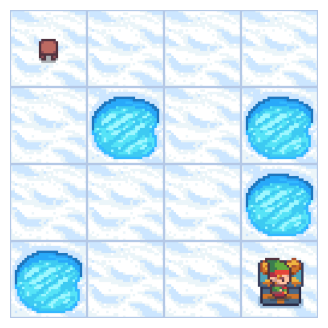

Episode 1/5 finished. steps=6, total_reward=1.0
Episode 2/5 finished. steps=6, total_reward=1.0
Episode 3/5 finished. steps=6, total_reward=1.0
Episode 4/5 finished. steps=6, total_reward=1.0
Episode 5/5 finished. steps=6, total_reward=1.0


In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display
import time

# ----------------------------
# Env
# ----------------------------
env = gym.make(
    "FrozenLake-v1",
    desc=None,
    map_name="4x4",
    is_slippery=False,              # deterministic (easier for Q-learning)
    success_rate=1.0/3.0,
    reward_schedule=(1, 0, 0),
    render_mode="rgb_array",
)

nS = env.observation_space.n
nA = env.action_space.n

# ----------------------------
# Q-learning
# ----------------------------
Q = np.zeros((nS, nA), dtype=np.float64)

alpha = 0.1
gamma = 0.99
eps_start, eps_end = 1.0, 0.05
eps_decay_steps = 5000

train_episodes = 8000
max_steps = 200

step_count = 0
for ep in range(train_episodes):
    s, _ = env.reset()
    done = False

    for t in range(max_steps):
        # epsilon schedule
        eps = eps_end + (eps_start - eps_end) * np.exp(-step_count / eps_decay_steps)
        step_count += 1

        # epsilon-greedy action
        if np.random.rand() < eps:
            a = env.action_space.sample()
        else:
            a = int(np.argmax(Q[s]))

        s2, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        # Q update
        td_target = r + (0.0 if done else gamma * np.max(Q[s2]))
        Q[s, a] += alpha * (td_target - Q[s, a])

        s = s2
        if done:
            break

# greedy policy from Q
pi = np.argmax(Q, axis=1).astype(int)
print("Learned policy (0=Left,1=Down,2=Right,3=Up):")
print(pi.reshape(4, 4))

# ----------------------------
# Render a few episodes using learned policy
# ----------------------------
episodes = 5
delay = 0.25

fig, ax = plt.subplots(figsize=(4, 4))
ax.axis("off")

s, _ = env.reset()
frame = env.render()
im = ax.imshow(frame)
disp = display(fig, display_id=True)

for ep in range(episodes):
    s, _ = env.reset()
    terminated = truncated = False
    total_reward = 0.0
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        a = int(pi[s])
        s, r, terminated, truncated, _ = env.step(a)
        total_reward += r
        steps += 1

        frame = env.render()
        im.set_data(frame)
        disp.update(fig)
        time.sleep(delay)

    print(f"Episode {ep+1}/{episodes} finished. steps={steps}, total_reward={total_reward}")

plt.close(fig)
env.close()